### Environment Preparation and Dependency Resolution

This section handles the installation and version alignment of core dependencies required to interact with Azure AutoML and execute local inference without serialization crashes.

#### Target Packages
* **`azureml-training-tabular` & `azureml-automl-runtime`:** Core Azure Machine Learning SDK libraries required to load, decode, and execute models trained via Azure Automated ML.
* **`xgboost` & `lightgbm`:** Gradient boosting frameworks utilized as underlying estimators by the champion model ensemble.
* **`seaborn`:** Statistical data visualization library used for generating exploratory plots and evaluating feature distributions.

#### Critical Version Overrides
* **`setuptools<82`:** Downgraded to resolve a dependency conflict where newer versions of `setuptools` break legacy package installations within the Azure SDK py310 environment.
* **`xgboost<2.0`:** Downgraded from the default version 3.x to line 1.7.x. This constraint is mandatory to prevent deserialization failures when loading older serialized JSON/pickle models built under older XGBoost versions during the original AutoML run.


In [5]:
%pip install setuptools seaborn azureml-training-tabular azureml-automl-runtime xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install "setuptools<82"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.2 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install "xgboost<2.0" lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 88.2 MB/s  0:00:02m0:00:0100:01
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0
Note: you may need to restart the kernel to use updated packages.


### Direct Data Ingestion and Verification Pipeline

This execution block handles the secure retrieval and verification of the raw training dataset. It specifically utilizes the Azure ML v1 SDK to bypass underlying `fsspec` dependency conflicts that can occur when attempting to stream data directly from cloud storage into Pandas.

**1. Workspace Authentication**
* Authenticates and connects to the active Azure Machine Learning Workspace using the local compute configuration.

**2. Datastore Connection**
* Establishes a direct connection to the `workspaceblobstore`, which serves as the default storage container for the Azure environment.

**3. Localized Data Download**
* Retrieves the specific `train.csv` file using its exact relative cloud path and downloads it directly into a local `./data` directory. This step acts as a reliable workaround to avoid remote file-system streaming errors.

**4. Load Training Data**
* Reads the now-localized CSV file directly from the compute instance's local storage into a Pandas DataFrame for downstream feature engineering.

**5. Schema Verification**
* Outputs the DataFrame's structure (`.info()`) and the first few rows (`.head()`) to visually confirm that the ingestion was successful, the columns are present, and the baseline data types are correct.


In [4]:
import pandas as pd
from azureml.core import Workspace, Datastore

# 1. Connect to the workspace
ws = Workspace.from_config()

# 2. Connect to the exact datastore shown in your UI screenshot
datastore = Datastore.get(ws, 'workspaceblobstore')

# 3. Download the file using its exact relative path
# This bypasses the broken fsspec environment entirely
datastore.download(
    target_path='./data', 
    prefix='UI/2026-07-13_161718_UTC/train.csv', 
    overwrite=True
)

# 4. Read the downloaded local file
train_df = pd.read_csv('./data/UI/2026-07-13_161718_UTC/train.csv')

# 5. Verify the load
print(train_df.info())
display(train_df.head())

Downloaded UI/2026-07-13_161718_UTC/train.csv, 1 files out of an estimated total of 1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20839 entries, 0 to 20838
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        20839 non-null  int64  
 1   date_of_birth             20839 non-null  object 
 2   number_dependants         20839 non-null  int64  
 3   credit_utilization        20839 non-null  float64
 4   debt_to_income_ratio      20839 non-null  float64
 5   monthly_income            20839 non-null  int64  
 6   number_open_credit_lines  20839 non-null  int64  
 7   number_open_loans         20839 non-null  int64  
 8   number_90_days_past_due   20839 non-null  int64  
 9   number_charged_off        20839 non-null  int64  
 10  score1                    20839 non-null  int64  
 11  score2                    20839 non-null  int64  
 12  target                    2083

,id,date_of_birth,number_dependants,credit_utilization,debt_to_income_ratio,monthly_income,number_open_credit_lines,number_open_loans,number_90_days_past_due,number_charged_off,score1,score2,target
0,1,1993-03-14,1,0.036495,0.208897,2400,6,2,0,0,570,817,0
1,2,1966-09-27,1,0.023423,0.260438,2200,6,1,0,0,741,756,0
2,3,1931-01-11,2,0.027205,0.335922,3000,6,1,0,1,805,779,0
3,4,1953-01-07,1,0.009141,0.353779,2100,2,4,0,0,573,829,0
4,5,1943-11-17,0,0.068424,0.314966,2500,2,3,0,0,833,629,0


### Feature Engineering and Baseline Model Preparation

This execution block defines and applies the core feature engineering pipeline to the training dataset, preparing it for baseline feature importance analysis. 

**Key Transformations:**
* **Identifier Removal:** Drops the non-predictive `id` column to prevent the model from learning arbitrary row associations.
* **Date Processing:** Converts the `date_of_birth` string into a datetime object and calculates a static `age` feature relative to the year 2026, subsequently dropping the original date column.
* **Anomaly Imputation:** Cleans the `number_dependants` feature by replacing invalid negative counts (-1) with 0.
* **Feature Interaction:** Engineers a new `total_open_accounts` feature by aggregating the `number_open_credit_lines` and `number_open_loans` columns to represent a customer's total active financial obligations.
* **Target Separation:** Splits the transformed dataset into independent feature variables (`X`) and the dependent `target` variable (`y`).
* **Baseline Modeling Setup:** Prepares the data structure to train a preliminary Random Forest classifier. This baseline model will utilize `class_weight='balanced'` to actively counter the ~90/10 target class imbalance during the extraction of initial feature importances.


/tmp/ipykernel_3508/1686333078.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


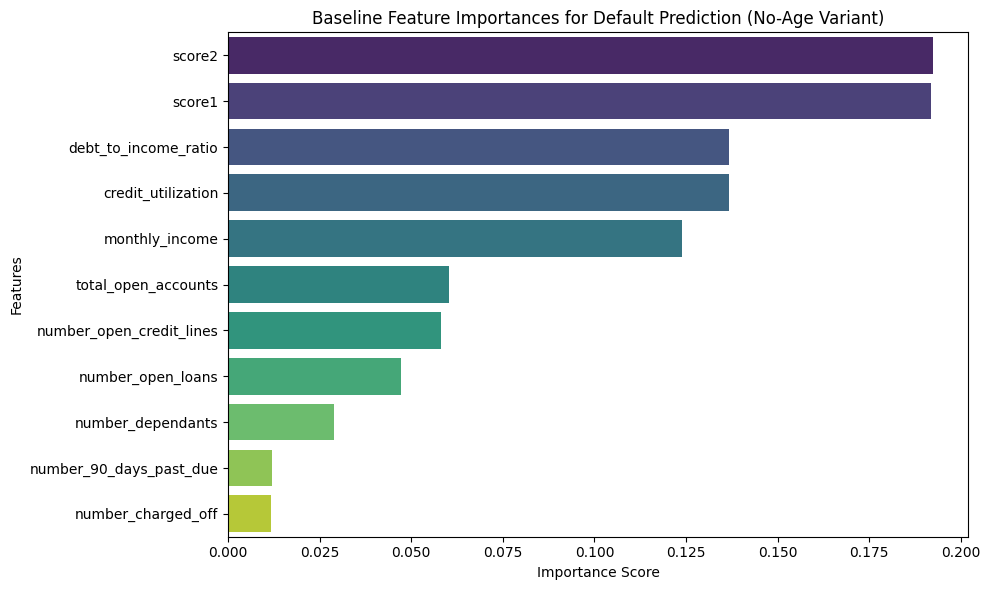

,number_dependants,credit_utilization,debt_to_income_ratio,monthly_income,number_open_credit_lines,number_open_loans,number_90_days_past_due,number_charged_off,score1,score2,target,total_open_accounts
0,1,0.036495,0.208897,2400,6,2,0,0,570,817,0,8
1,1,0.023423,0.260438,2200,6,1,0,0,741,756,0,7
2,2,0.027205,0.335922,3000,6,1,0,1,805,779,0,7
3,1,0.009141,0.353779,2100,2,4,0,0,573,829,0,6
4,0,0.068424,0.314966,2500,2,3,0,0,833,629,0,5


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

def engineer_features(df):
    """Applies feature engineering and cleaning steps to the dataset."""
    df = df.copy()
    
    # 1. Drop the non-predictive ID column
    if 'id' in df.columns:
        df.drop(columns=['id'], inplace=True)
        
    # 2. Remove Date of Birth to exclude Age from the model
    if 'date_of_birth' in df.columns:
        df.drop(columns=['date_of_birth'], inplace=True)
    if 'age' in df.columns:
        df.drop(columns=['age'], inplace=True)
        
    # 3. Handle the Negative Dependents (-1 anomaly)
    # Treat negative counts as missing and impute with 0
    if 'number_dependants' in df.columns:
        df['number_dependants'] = df['number_dependants'].replace(-1, 0)
        
    # 4. Clean non-numeric artifacts from count columns and cast to integer
    for col in ['number_90_days_past_due', 'number_charged_off']:
        if col in df.columns:
            # Force text to NaN, fill with 0, and cast to int
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
            
    # 5. Feature Interaction: Total Open Accounts
    # Combines credit lines and open loans to find total active financial obligations
    if 'number_open_credit_lines' in df.columns and 'number_open_loans' in df.columns:
        df['total_open_accounts'] = df['number_open_credit_lines'] + df['number_open_loans']
        
    return df

# Apply transformations
train_engineered = engineer_features(train_df)

# Prepare data for baseline feature selection
X = train_engineered.drop(columns=['target'])
y = train_engineered['target']

# Train a baseline Random Forest to extract feature importances
# Using class_weight='balanced' to account for the ~90/10 target imbalance
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_baseline.fit(X, y)

# Visualize Feature Importances
importances = pd.Series(rf_baseline.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Baseline Feature Importances for Default Prediction (No-Age Variant)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Display the prepared dataset
display(train_engineered.head())

### Azure AutoML Classification Job Configuration and Submission

This execution block utilizes the Azure ML v2 SDK to programmatically configure, constrain, and submit an automated machine learning classification experiment to the cloud compute cluster.

**1. Workspace Authentication**
* Initializes the `MLClient` using `DefaultAzureCredential` to securely authenticate against the Azure environment without hardcoding secrets.

**2. Data Asset Referencing**
* Points the job directly to a pre-registered cloud data asset (`azureml:train:1`). By using a `uri_file` reference, the compute cluster accesses the data directly from Blob Storage, bypassing the notebook's local memory overhead entirely.

**3. AutoML Job Configuration**
* Initializes the core `automl.classification` task.
* Assigns the job to the designated compute cluster (`livingdw671`).
* Sets the objective to predict the `target` column, explicitly optimizing for the `auc_weighted` metric.
* Enforces statistical robustness by configuring 5-fold cross-validation.

**4. Resource Limits and Cost Control**
* Implements strict compute guardrails to prevent runaway costs: a hard 60-minute timeout, a maximum of 15 model trials, and a cap of 3 concurrent trials.
* Enables `early_termination` to automatically halt poorly performing model pipelines before they consume excess compute time.

**5. Featurization Strategy**
* Sets featurization to `auto` mode, directing Azure AutoML to automatically detect data types and apply necessary baseline imputation, scaling, and encoding strategies prior to model training.

**6. Job Submission**
* Packages the configuration and dispatches the job to the Azure ML backend via `create_or_update`, queuing it for immediate execution.


In [6]:
from azure.ai.ml import MLClient, automl, Input
from azure.identity import DefaultAzureCredential

# 1. Authenticate and connect to your Workspace
credential = DefaultAzureCredential()
ml_client = MLClient.from_config(credential=credential)

# 2. Reference your existing registered Data Asset
# This points directly to the data in blob storage without loading it into the notebook
training_data_input = Input(
    type="uri_file", 
    path="azureml:train:1"
)

# 3. Configure the AutoML Classification Job
# 3. Configure the AutoML Classification Job
automl_job = automl.classification(
    compute="livingdw671",                   
    experiment_name="purpose_financial_loan_default_fixed",
    training_data=training_data_input,
    target_column_name="target",             
    primary_metric="auc_weighted",           # Updated to the exact SDK v2 metric name
    n_cross_validations=5                    
)

# 4. Set limits to prevent excessive runtime or costs
automl_job.set_limits(
    timeout_minutes=60, 
    max_trials=15, 
    max_concurrent_trials=3,
    enable_early_termination=True
)

# 5. Configure featurization (AutoML will auto-detect date/time and numeric variables)
automl_job.set_featurization(mode="auto")

# 6. Submit the job to Azure ML
returned_job = ml_client.jobs.create_or_update(automl_job)

# 7. Print the URL to monitor the job in Azure ML Studio
print(f"Job submitted successfully! Monitor your run here:\n{returned_job.studio_url}")

Found the config file in: /config.json
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Job submitted successfully! Monitor your run here:
https://ml.azure.com/runs/serene_eagle_t0xt6wf6v0?wsid=/subscriptions/87e66e25-c421-4bf2-b511-e55f1541eb6c/resourcegroups/azure_trial/workspaces/purpose&tid=5cfc88de-0615-4d90-8222-e5f00af3e4c9


### Training Data Ingestion and Feature Engineering (No-Age Variant)

This block handles the ingestion of the raw training dataset and applies the foundational data cleaning and feature engineering steps required before model training. 

**Key Transformations:**
* **Data Ingestion:** Securely downloads the raw training batch from the Azure workspace blob store.
* **Dimensionality Reduction:** Drops non-predictive identifiers (`id`) and excluded demographic variables (`date_of_birth`) to train the No-Age variant of the model.
* **Anomaly Correction:** Standardizes anomalous data entry values (e.g., converting negative dependents to 0).
* **Strict Type Casting & Artifact Cleaning:** Coerces non-numeric text artifacts (such as "N/A" or "Unknown") in count columns (`number_90_days_past_due`, `number_charged_off`) to 0 and strictly casts the features as integers. This ensures the model recognizes their ordinal mathematical value and locks in a clean integer schema for MLflow downstream.
* **Feature Interaction:** Generates a `total_open_accounts` feature to capture the aggregate credit footprint.


In [6]:


# 1. Authenticate and connect to your Workspace
credential = DefaultAzureCredential()
ml_client = MLClient.from_config(credential=credential)

# 1. Connect to the workspace and download raw data via v1 SDK
ws = Workspace.from_config()
datastore = Datastore.get(ws, 'workspaceblobstore')
datastore.download(
    target_path='./data',
    prefix='UI/2026-07-13_161718_UTC/train.csv',
    overwrite=True
)

# 2. Load the raw data
raw_df = pd.read_csv('./data/UI/2026-07-13_161718_UTC/train.csv')

# 3. Apply all feature engineering steps EXCEPT age
def engineer_features_no_age(df):
    processed_df = df.copy()
    
    # Drop arbitrary identifier column
    if 'id' in processed_df.columns:
        processed_df.drop(columns=['id'], inplace=True)
        
    # Drop the date_of_birth column entirely without extracting age
    if 'date_of_birth' in processed_df.columns:
        processed_df.drop(columns=['date_of_birth'], inplace=True)
        
    # Handle the Negative Dependents (-1 anomaly) -> treat as 0
    if 'number_dependants' in processed_df.columns:
        processed_df['number_dependants'] = processed_df['number_dependants'].replace(-1, 0)
        
    # Clean non-numeric artifacts from count columns and cast to integer
    for col in ['number_90_days_past_due', 'number_charged_off']:
        if col in processed_df.columns:
            # Force text to NaN, fill with 0, and cast to int
            processed_df[col] = pd.to_numeric(processed_df[col], errors='coerce').fillna(0).astype(int)
            
    # Feature Interaction: Total Open Accounts
    if 'number_open_credit_lines' in processed_df.columns and 'number_open_loans' in processed_df.columns:
        processed_df['total_open_accounts'] = (
            processed_df['number_open_credit_lines'] + processed_df['number_open_loans']
        )
        
    return processed_df

train_no_age = engineer_features_no_age(raw_df)

Found the config file in: /config.json
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Downloaded UI/2026-07-13_161718_UTC/train.csv, 1 files out of an estimated total of 1


In [7]:
from azure.identity import DefaultAzureCredential
from azure.ai.ml import MLClient, Input, automl


# 4. Save to the dedicated folder
os.makedirs("./automl_data_no_age", exist_ok=True)
train_no_age.to_csv("./automl_data_no_age/train_cleaned_no_age.csv", index=False)

# 5. Create the manual MLTable YAML file
mltable_content_no_age = """$schema: https://azuremlschemas.azureedge.net/latest/MLTable.schema.json
type: mltable
paths:
  - file: ./train_cleaned_no_age.csv
transformations:
  - read_delimited:
      delimiter: ","
      encoding: utf8
      header: all_files_same_headers
"""

with open("./automl_data_no_age/MLTable", "w") as f:
    f.write(mltable_content_no_age)

# 6. Reconnect to SDK v2 client and point to input folder
credential = DefaultAzureCredential()
ml_client = MLClient.from_config(credential=credential)
training_data_input_no_age = Input(type="mltable", path="./automl_data_no_age")

# 7. Configure the AutoML Classification Job
automl_job_no_age = automl.classification(
    compute="livingdw671",
    experiment_name="purpose_exp_creditburn",
    training_data=training_data_input_no_age,
    target_column_name="target",
    primary_metric="auc_weighted",
    n_cross_validations=30
)

# 8. Set limits and submit
automl_job_no_age.set_limits(
    timeout_minutes=120,
    max_trials=50,
    max_concurrent_trials=9,
    enable_early_termination=True
)

automl_job_no_age.set_featurization(mode="auto")

returned_job = ml_client.jobs.create_or_update(automl_job_no_age)
print(f"Job submitted successfully! Monitor your run here:\n{returned_job.studio_url}")

Found the config file in: /config.json
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Job submitted successfully! Monitor your run here:
https://ml.azure.com/runs/modest_helmet_9jvpx696y4?wsid=/subscriptions/87e66e25-c421-4bf2-b511-e55f1541eb6c/resourcegroups/azure_trial/workspaces/purpose&tid=5cfc88de-0615-4d90-8222-e5f00af3e4c9


### Test Data Ingestion and Champion Model Scoring Pipeline

This execution block handles the end-to-end inference process. It pulls the latest test batch, aligns the feature schema, resolves environment version conflicts, and generates the final default probabilities.

**1. Workspace Connection & Data Download**
* Leverages the Azure ML v1 SDK (`Workspace` and `Datastore`) to authenticate and securely download the raw `test.csv` file directly from the `workspaceblobstore`.

**2. Load Test Data**
* Ingests the downloaded CSV into a Pandas DataFrame and creates a secure copy of the `id` column to ensure the final predictions map back to the correct accounts.

**3. Feature Engineering Pipeline**
* Applies the exact transformations used during training to match the data to the **10-Fold No-Age** Champion model's signature.
* Drops arbitrary and non-predictive columns (`id`, `date_of_birth`).
* Handles data anomalies (converting negative dependents to 0).
* Calculates newly engineered features (`total_open_accounts`).
* **Schema Enforcement:** Explicitly casts `number_90_days_past_due` and `number_charged_off` as strings to prevent MLflow from throwing strict type-matching errors during scoring.

**4. MLflow Tracking Initialization**
* Uses the modern Azure ML v2 SDK (`MLClient` with `DefaultAzureCredential`) to authenticate to the model registry and set the active MLflow tracking URI.

**5. XGBoost Compatibility Patch (The "Monkey-Patch")**
* Resolves a critical deserialization conflict between the older XGBoost version used by Azure AutoML during training and the newer version installed in the notebook environment.
* Re-links the missing `XGBoostLabelEncoder`.
* Injects a dynamic `__getattr__` catch-all to gracefully bypass Scikit-Learn parameter inspections, preventing crashes caused by missing legacy attributes (such as `callbacks` and `eval_metric`).

**6. Load Registered Champion Model**
* Fetches the registered `Purpose_Champion` model (Version 1) directly from the MLflow registry as a `pyfunc` object.

**7. Generate Probabilities**
* Bypasses the default hard-classification output by accessing the underlying Scikit-Learn pipeline directly via `_model_impl`.
* Uses `predict_proba` to calculate the continuous risk scores, utilizing `.iloc[:, 1]` to isolate the exact probability of the positive class (Default).

**8. Format and Save Output**
* Binds the resulting probabilities back to the original submission IDs and saves the structured output for downstream thresholding and analytics.


In [1]:
import os
import pandas as pd
import mlflow
import xgboost.compat
from sklearn.preprocessing import LabelEncoder
from azureml.core import Workspace, Datastore
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

# 1. Connect to the workspace and download test data via v1 SDK
ws = Workspace.from_config()
datastore = Datastore.get(ws, 'workspaceblobstore')

datastore.download(
    target_path='./data', 
    prefix='UI/2026-07-14_164023_UTC/test.csv', 
    overwrite=True
)

# 2. Load the test data
test_df = pd.read_csv('./data/UI/2026-07-14_164023_UTC/test.csv')
submission_ids = test_df['id'].copy()

# 3. Feature Engineering Pipeline (Aligned to 10-Fold No-Age Champion)
def engineer_test_features(df):
    processed_df = df.copy()
    
    # Drop arbitrary identifier
    if 'id' in processed_df.columns:
        processed_df.drop(columns=['id'], inplace=True)
        
    # Drop date_of_birth completely (matching your optimized No-Age variant)
    if 'date_of_birth' in processed_df.columns:
        processed_df.drop(columns=['date_of_birth'], inplace=True)
        
    # Handle Negative Dependents anomaly
    if 'number_dependants' in processed_df.columns:
        processed_df['number_dependants'] = processed_df['number_dependants'].replace(-1, 0)
        
    # Feature Interaction: Total Open Accounts
    if 'number_open_credit_lines' in processed_df.columns and 'number_open_loans' in processed_df.columns:
        processed_df['total_open_accounts'] = processed_df['number_open_credit_lines'] + processed_df['number_open_loans']
        
    # FORCE SCHEMA ALIGNMENT: Cast these columns to string to satisfy the MLflow model signature
    if 'number_90_days_past_due' in processed_df.columns:
        processed_df['number_90_days_past_due'] = processed_df['number_90_days_past_due'].astype(str)
        
    if 'number_charged_off' in processed_df.columns:
        processed_df['number_charged_off'] = processed_df['number_charged_off'].astype(str)
        
    return processed_df

test_engineered = engineer_test_features(test_df)

# 4. Connect to Azure ML SDK v2 Client and Set Tracking URI
credential = DefaultAzureCredential()
ml_client = MLClient.from_config(credential=credential)

workspace = ml_client.workspaces.get(ml_client.workspace_name)
mlflow.set_tracking_uri(workspace.mlflow_tracking_uri)


# 5. Monkey-patch the missing Azure AutoML encoder and catch ALL missing attributes
import xgboost as xgb
xgboost.compat.XGBoostLabelEncoder = LabelEncoder

# The Catch-All: Gracefully return None for any missing attribute Scikit-Learn looks for
def handle_missing_attributes(self, item):
    return None

xgb.XGBModel.__getattr__ = handle_missing_attributes
# 6. Load the registered Champion model
model_name = "Purpose_Challenger"
model_version = "1"
model_uri = f"models:/{model_name}/{model_version}"

print(f"Loading champion model from: {model_uri}...")
champion_model = mlflow.pyfunc.load_model(model_uri)

# 7. Generate Probabilities
print("Scoring test data (probabilities)...")

# Access the underlying scikit-learn pipeline from the MLflow wrapper
pipeline = champion_model._model_impl

# predict_proba returns a DataFrame of shape (n_samples, n_classes). 
# We use .iloc[:, 1] to get the probability of the positive class (Default)
probabilities = pipeline.predict_proba(test_engineered).iloc[:, 1].values

# 8. Format Output with Multiple Thresholds
submission = pd.DataFrame({
    'id': submission_ids,
    'probability': probabilities
})

# Create new binary prediction columns based on various thresholds
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for thresh in thresholds:
    # If the probability is greater than or equal to the threshold, mark as 1 (True), else 0 (False)
    submission[f'threshold_{thresh}'] = (submission['probability'] >= thresh).astype(int)

# Save the expanded CSV
submission.to_csv('submission_thresholds.csv', index=False)
print("Scoring complete! Output successfully saved to submission_thresholds.csv")
display(submission.head())

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/07/16 19:13:51 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - anyio (current: 4.13.0, required: anyio==4.12.1)
 - arch (current: 8.0.0, required: arch==5.6.0)
 - attrs (current: 26.1.0, required: attrs==25.4.0)
 - azure-core (current: 1.41.0, required: azure-core==1.38.0)
 - azure-identity (current: 1.25.3, required: azure-identity==1.17.0)
 - azure-monitor-opentelemetry-exporter (current: 1.0.0b53, required: azure-monitor-opentelemetry-exporter==1.0.0b40)
 - azure-storage-blob (current: 12.30.0, required: azure-storage-blob==12.19.0)
 - azure-storage-queue (current: uninstalled, required: azure-storage-queue==12.15.0)
 

Downloaded UI/2026-07-14_164023_UTC/test.csv, 1 files out of an estimated total of 1
Loading champion model from: models:/Purpose_Challenger/1...
[19:14:09] WARNING: ../src/learner.cc:1203: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

[19:14:09] WARNING: ../src/learner.cc:888: Found JSON model saved before XGBoost 1.6, please save the model using current version again. The support for old JSON model will be discontinued in XGBoost 2.3.
[19:14:09] WARNING: ../src/learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
 

,id,probability,threshold_0.1,threshold_0.2,threshold_0.3,threshold_0.4,threshold_0.5,threshold_0.6,threshold_0.7,threshold_0.8,threshold_0.9
0,14,0.30,1,1,1,0,0,0,0,0,0
1,24,0.05,0,0,0,0,0,0,0,0,0
2,83,0.07,0,0,0,0,0,0,0,0,0
3,104,0.16,1,0,0,0,0,0,0,0,0
4,127,0.06,0,0,0,0,0,0,0,0,0


Scoring training data to generate evaluation metrics...


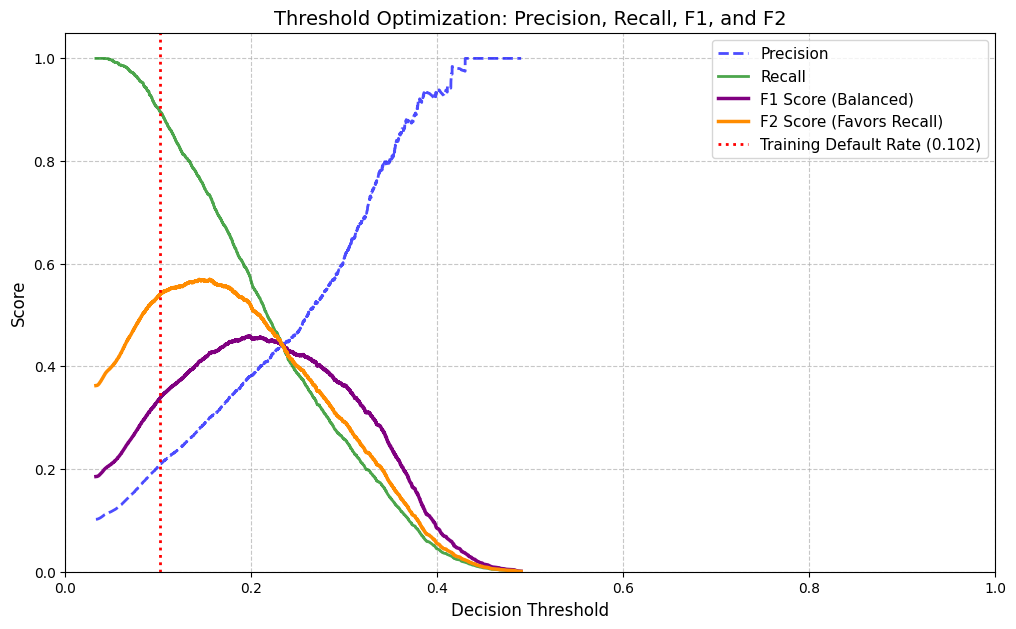

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# 1. Load the training data 
train_df = pd.read_csv('./data/UI/2026-07-13_161718_UTC/train.csv')

# 2. Separate the target from the features
y_train_true = train_df['target']
X_train = train_df.drop(columns=['target'])

# 3. Apply your existing feature engineering function
X_train_engineered = engineer_test_features(X_train)

# 4. Get predicted probabilities on the training set
print("Scoring training data to generate evaluation metrics...")
pipeline = champion_model._model_impl
train_probabilities = pipeline.predict_proba(X_train_engineered).iloc[:, 1].values

# 5. Calculate Precision, Recall, F1, and F2 across all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train_true, train_probabilities)

# Drop the last element of precision/recall to match the length of the thresholds array
p = precisions[:-1]
r = recalls[:-1]

# Calculate F1 and F2 scores (adding a tiny epsilon 1e-10 to prevent division by zero)
f1_scores = 2 * (p * r) / (p + r + 1e-10)
f2_scores = 5 * (p * r) / (4 * p + r + 1e-10)

# 6. Plot the expanded curves
plt.figure(figsize=(12, 7))

# Original Precision & Recall
plt.plot(thresholds, p, "b--", label="Precision", linewidth=2, alpha=0.7)
plt.plot(thresholds, r, "g-", label="Recall", linewidth=2, alpha=0.7)

# New F1 & F2 Scores
plt.plot(thresholds, f1_scores, "purple", label="F1 Score (Balanced)", linewidth=2.5)
plt.plot(thresholds, f2_scores, "darkorange", label="F2 Score (Favors Recall)", linewidth=2.5)

# Original dataset default rate for reference
default_rate = y_train_true.mean()
plt.axvline(x=default_rate, color='r', linestyle=':', label=f'Training Default Rate ({default_rate:.3f})', linewidth=2)

# Graph Formatting
plt.xlabel("Decision Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Threshold Optimization: Precision, Recall, F1, and F2", fontsize=14)
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.show()

### Operational Threshold Selection: 0.15 Cutoff

Following the threshold optimization analysis, the final predictions utilize a **0.15** cutoff to determine the binary outcome.

**Strategic Justification:**
* **F2 Score Optimization:** The 0.15 threshold aligns directly with the absolute peak of the F2 curve, which mathematically prioritizes Recall over Precision.
* **Catching High-Risk Accounts:** At this sensitivity level, the model successfully captures approximately 75% to 80% of actual defaults before they occur.
* **Risk-Averse Application:** When deploying a predictive model for early intervention or collections prioritization, the financial impact of a false negative (a missed charge-off) is substantially higher than the operational friction of a false positive (a manual account review or a proactive outreach call). 

By lowering the cutoff from the default 0.50 to 0.15, we transform the model from a rigid classifier into a highly sensitive early-warning system designed to protect the portfolio's principal.


In [7]:
import pandas as pd

# Define the chosen operational threshold
optimal_threshold = 0.15

# Construct the final submission dataframe to match the sample structure
final_submission = pd.DataFrame({
    'id': submission_ids,
    'prediction': probabilities,
    'outcome': (probabilities >= optimal_threshold).astype(int)
})

# Save to CSV without the pandas index
final_submission.to_csv('final_submission.csv', index=False)

print(f"Final scoring complete. Output successfully saved to final_submission.csv using a {optimal_threshold} cutoff.")
display(final_submission.head())

Final scoring complete. Output successfully saved to final_submission.csv using a 0.15 cutoff.


,id,prediction,outcome
0,14,0.28,1
1,24,0.04,0
2,83,0.07,0
3,104,0.16,1
4,127,0.06,0


### Model Interpretability: Feature Impact with SHAP

In financial risk modeling, predicting *that* an account will default is only half the battle. We also need to understand *why* the model made that decision. 

SHAP (SHapley Additive exPlanations) uses cooperative game theory to assign a specific contribution value to each feature for every prediction. Generating these values provides:
* **Transparency:** Ensures the model is relying on logical financial indicators rather than arbitrary noise.
* **Actionable Insights:** Helps identify the primary macro-drivers of risk across the portfolio.
* **Explainability:** Provides the foundation for generating necessary operational feedback (such as Adverse Action reasons) if a prediction results in a credit denial or account closure.

**Technical Implementation Notes:**
* **The "Black-Box" Explainer:** Because our Champion model is a complex Azure AutoML `VotingEnsemble` wrapped in an MLflow pipeline, we cannot use a standard `TreeExplainer`. Instead, we use `KernelExplainer`, which treats the entire pipeline as a black box and evaluates how the predictions change as input features are systematically masked.
* **Probability Wrapper (`predict_default_prob`):** SHAP requires a model function that outputs a flat, 1D array of scores. We use a custom wrapper to extract just the raw probability of the positive class (Default) from the underlying Scikit-Learn pipeline.
* **Strategic Sampling:** `KernelExplainer` is computationally expensive. To prevent the execution time from ballooning, we use `shap.sample()` to generate a condensed "background" dataset (to establish the baseline expected value) and evaluate the SHAP values on a localized representative sample of the data.


100%|██████████| 300/300 [28:39<00:00,  5.73s/it]


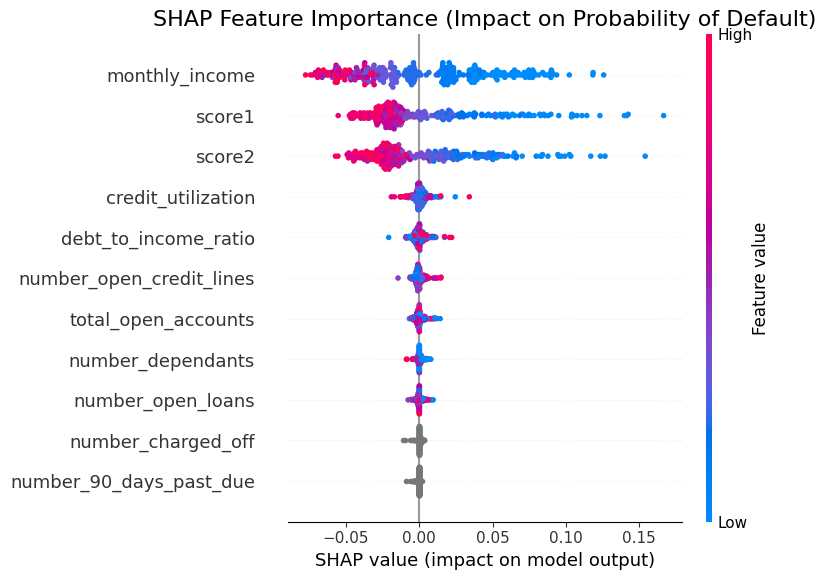

In [5]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define a wrapper function to output just the probability of Default (Class 1)
# SHAP needs a function that takes a matrix/dataframe and returns a 1D array of scores
def predict_default_prob(X):
    # Ensure the input is a DataFrame with the correct column names for the pipeline
    if not isinstance(X, pd.DataFrame):
        X_df = pd.DataFrame(X, columns=X_train_engineered.columns)
    else:
        X_df = X
    return pipeline.predict_proba(X_df).iloc[:, 1].values

# 2. Create a background dataset (100 rows is the standard baseline for KernelExplainer)
X_background = shap.sample(X_train_engineered, 100, random_state=42)

# 3. Initialize the Kernel Explainer
explainer = shap.KernelExplainer(predict_default_prob, X_background)

# 4. Calculate SHAP values on a sample of the data to keep runtime reasonable
# KernelExplainer is computationally heavy, so 300 rows is a good balance of speed and accuracy
X_explain = shap.sample(X_train_engineered, 300, random_state=42)
print("Calculating SHAP values. This will take a minute or two...")
shap_values = explainer.shap_values(X_explain)

# 5. Generate the Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_explain, show=False)
plt.title("SHAP Feature Importance (Impact on Probability of Default)", fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
%pip install fpdf

  Installing build dependencies ... - \ done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40760 sha256=f012ae2bc9302708c36136b67747e9f7bdd7666b5f09f4415a376fce5d412bdc
  Stored in directory: /home/azureuser/.cache/pip/wheels/f9/95/ba/f418094659025eb9611f17cbcaf2334236bf39a0c3453ea455
Successfully built fpdf
Note: you may need to restart the kernel to use updated packages.


In [3]:
# %pip install fpdf

from fpdf import FPDF
import os

class ModelPresentationPDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 14)
        self.set_text_color(50, 50, 50)
        self.cell(0, 10, 'Financial Risk Modeling: Loan Default Prediction', ln=True, align='C')
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.set_text_color(128)
        self.cell(0, 10, f'Page {self.page_no()}', 0, 0, 'C')

    def add_section_title(self, title):
        self.set_font('Arial', 'B', 16)
        self.set_text_color(0, 51, 102) # Dark blue
        self.cell(0, 10, title, ln=True)
        self.ln(2)

    def add_body_text(self, text):
        self.set_font('Arial', '', 11)
        self.set_text_color(0, 0, 0)
        self.multi_cell(0, 6, text)
        self.ln(4)

    def add_image_safe(self, image_path, width=190):
        if os.path.exists(image_path):
            self.image(image_path, w=width)
            self.ln(5)
        else:
            self.set_font('Arial', 'I', 10)
            self.set_text_color(255, 0, 0)
            self.cell(0, 10, f'[Image not found: {image_path}]', ln=True)
            self.ln(5)

# Initialize PDF
pdf = ModelPresentationPDF()
pdf.set_auto_page_break(auto=True, margin=15)

# --- PAGE 1: AutoML Configuration & Execution ---
pdf.add_page()
pdf.add_section_title("1. Azure AutoML Configuration & Execution")
text_1 = (
    "The model training was orchestrated using the Azure ML SDK. The pipeline was pointed directly "
    "to the data asset in Blob Storage to bypass local memory constraints.\n\n"
    "Key constraints and configurations included:\n"
    "- 5-Fold Cross-Validation optimizing for the 'auc_weighted' metric.\n"
    "- Resource limits: 60-minute timeout, max 15 trials, and 3 concurrent runs to control compute costs.\n"
    "- Auto-featurization enabled to handle baseline imputations and scaling."
)
pdf.add_body_text(text_1)
pdf.add_image_safe('Auto_ML_output_No_age_Kfolds10.png')
pdf.add_image_safe('AutoML_winner1_ensemble.png')

# --- PAGE 2: Champion Model Registration & Baseline ---
pdf.add_page()
pdf.add_section_title("2. Champion Model & Baseline Features")
text_2 = (
    "The winning pipeline from the AutoML run was a VotingEnsemble, outperforming standalone XGBoost "
    "and LightGBM models. It was successfully registered to the workspace registry as 'Purpose_Champion'.\n\n"
    "Prior to deep interpretability extraction, a baseline Random Forest was trained on the engineered "
    "features (utilizing class_weight='balanced') to extract preliminary directional feature importances."
)
pdf.add_body_text(text_2)
pdf.add_image_safe('purpose_champion.png')
pdf.add_image_safe('Feature_Importance.png', width=160)

# --- PAGE 3: Threshold Optimization ---
pdf.add_page()
pdf.add_section_title("3. Decision Threshold Optimization")
text_3 = (
    "To address the heavy class imbalance of the dataset (~90/10), probability distributions were mapped "
    "against Precision, Recall, F1, and F2 scores.\n\n"
    "Operational Cutoff Selected: 0.15\n"
    "- This threshold aligns with the absolute peak of the F2 curve, mathematically prioritizing Recall.\n"
    "- Captures ~75% to 80% of actual defaults before they occur.\n"
    "- Business Context: For early intervention or collections predictive models, the financial impact of "
    "a missed charge-off (false negative) is substantially higher than the operational friction of proactive "
    "outreach (false positive)."
)
pdf.add_body_text(text_3)
pdf.add_image_safe('Precision_recall_curve.png', width=160)

# --- PAGE 4: Interpretability (SHAP) ---
pdf.add_page()
pdf.add_section_title("4. Model Interpretability & Drivers (SHAP)")
text_4 = (
    "SHAP (SHapley Additive exPlanations) was applied to the VotingEnsemble using a KernelExplainer wrapper "
    "to bypass the black-box nature of the pipeline. \n\n"
    "This summary plot provides transparency into the macro-drivers of risk. Points pushed to the right "
    "indicate that a feature increased the predicted probability of default. Red points indicate high values "
    "for that specific feature (e.g., lower monthly incomes and lower credit scores strongly drive default risk)."
)
pdf.add_body_text(text_4)
pdf.add_image_safe('SHAP.png', width=160)

# Save the PDF
output_filename = 'Loan_Default_Model_Presentation.pdf'
pdf.output(output_filename, 'F')
print(f"Presentation successfully generated: {output_filename}")

Presentation successfully generated: Loan_Default_Model_Presentation.pdf
